In [34]:
# %%
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# 1. Define Columns
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

# 2. Load the 20% dataset explicitly
df = pd.read_csv("nsl-kdd/KDDTrain+_20Percent.txt", header=None, names=columns)
print(f"Dataset Shape: {df.shape}")

# 3. Feature Selection
selected_features = [
    "duration", "src_bytes", "dst_bytes", "wrong_fragment", "urgent", "hot", 
    "num_failed_logins", "num_compromised", "count", "srv_count", "serror_rate", 
    "rerror_rate", "same_srv_rate", "diff_srv_rate", "dst_host_count"
]

X = df[selected_features].copy()
y = (df["label"] != "normal").astype(int).values

print(f"Normal: {(y==0).sum()}, Attack: {(y==1).sum()}")

# 4. Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch Tensors immediately
x_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

Dataset Shape: (25192, 43)
Normal: 13449, Attack: 11743


In [ ]:
# %%
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors
import numpy as np
import time

print("Constructing K-Nearest Neighbors Graph using Scikit-Learn...")
start_time = time.time()

# 1. Fit Scikit-Learn's KNN on the CPU
# We use n_neighbors=6 because the algorithm counts the node itself as the 1st neighbor
nn = NearestNeighbors(n_neighbors=6, metric='euclidean', n_jobs=-1)
nn.fit(X_scaled) # Use the numpy array from Cell 1

# 2. Get the indices of the neighbors
distances, indices = nn.kneighbors(X_scaled)

# 3. Exclude self-loops (drop the first column which is distance 0 to itself)
neighbors = indices[:, 1:]

# 4. Construct the edge_index array
# Repeat each source node 5 times (since k=5)
sources = np.repeat(np.arange(len(X_scaled)), 5)
# Flatten the neighbors matrix to match the sources
targets = neighbors.flatten()

# 5. Convert to PyTorch Tensor in the shape [2, num_edges]
edge_index = torch.tensor(np.vstack((sources, targets)), dtype=torch.long)

# Construct the PyG Data Object
data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)

print(f"Graph Construction Time: {time.time() - start_time:.2f} seconds")
print(f"Total Nodes: {data.num_nodes}")
print(f"Total Edges: {data.num_edges}")
print(f"Average edges per node: {data.num_edges / data.num_nodes:.2f}")

Constructing K-Nearest Neighbors Graph using Scikit-Learn...
Graph Construction Time: 9.20 seconds
Total Nodes: 25192
Total Edges: 125960
Average edges per node: 5.00


In [75]:
# %%
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# 1. Create Train/Val/Test Masks
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)

train_size = int(0.7 * num_nodes)
val_size   = int(0.15 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True

data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

# 2. Define the GCN
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # First Graph Convolution layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        # Second Graph Convolution layer
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(input_dim=15, hidden_dim=64, output_dim=2).to(device)
data = data.to(device)
print(model)

GCN(
  (conv1): GCNConv(15, 64)
  (conv2): GCNConv(64, 2)
)


In [78]:
import torch.nn as nn

class PaperInspiredGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, mlp_hidden_dim, output_dim):
        super().__init__()
        
        # --- 1. Graph Convolutional Layers (2 Hops as per paper) ---
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        
        # --- 2. The MLP Layer (Feature Refinement) ---
        # The paper systematically processes features retaining edge-informed characteristics
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden_dim),
            nn.BatchNorm1d(mlp_hidden_dim), # Added for stability
            nn.ReLU(),
            nn.Dropout(p=0.5),
            
            # --- 3. Final Classification Layer ---
            nn.Linear(mlp_hidden_dim, output_dim)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Graph Convolutions (Aggregation)
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        # Pass the aggregated node features into the MLP
        x = self.mlp(x)
        
        # Softmax activation as requested by the paper
        return F.log_softmax(x, dim=1)

# Initialize the new model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Example dimensions: 15 input features -> 64 GCN dims -> 32 MLP dims -> 2 classes
model = PaperInspiredGCN(
    input_dim=15, 
    hidden_dim=64, 
    mlp_hidden_dim=32, 
    output_dim=2
).to(device)

print(model)

PaperInspiredGCN(
  (conv1): GCNConv(15, 64)
  (conv2): GCNConv(64, 64)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [79]:
# %%
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F
import numpy as np

# Format: [Weight for Normal, Weight for Attack]
# 5.0 means we penalize the model 5x more for missing an attack (False Negative)
custom_weights = torch.tensor([1.0, 5.0], dtype=torch.float).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    
    # FIX IS HERE: Re-applied [data.train_mask] so it only learns from the training set
    loss = F.nll_loss(
        out[data.train_mask], 
        data.y[data.train_mask], 
        weight=custom_weights
    )
    
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)
        correct = (pred[mask] == data.y[mask]).sum()
        acc = correct / mask.sum()
    return acc.item()

# Training Execution
print("Starting Training...")
for epoch in range(1, 201):
    loss = train()
    if epoch % 20 == 0:
        train_acc = evaluate(data.train_mask)
        val_acc   = evaluate(data.val_mask)
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Starting Training...
Epoch 020 | Loss: 0.1925 | Train Acc: 0.8318 | Val Acc: 0.8322
Epoch 040 | Loss: 0.1543 | Train Acc: 0.9248 | Val Acc: 0.9381
Epoch 060 | Loss: 0.1302 | Train Acc: 0.9275 | Val Acc: 0.9362
Epoch 080 | Loss: 0.1243 | Train Acc: 0.9159 | Val Acc: 0.9227
Epoch 100 | Loss: 0.1166 | Train Acc: 0.9330 | Val Acc: 0.9381
Epoch 120 | Loss: 0.1095 | Train Acc: 0.9309 | Val Acc: 0.9373
Epoch 140 | Loss: 0.1052 | Train Acc: 0.9430 | Val Acc: 0.9449
Epoch 160 | Loss: 0.1079 | Train Acc: 0.9405 | Val Acc: 0.9442
Epoch 180 | Loss: 0.0999 | Train Acc: 0.9446 | Val Acc: 0.9428
Epoch 200 | Loss: 0.0942 | Train Acc: 0.9456 | Val Acc: 0.9500



--- GNN Classification Report ---
              precision    recall  f1-score   support

      Normal       0.97      0.86      0.91      2009
      Attack       0.86      0.97      0.91      1771

    accuracy                           0.91      3780
   macro avg       0.91      0.91      0.91      3780
weighted avg       0.92      0.91      0.91      3780



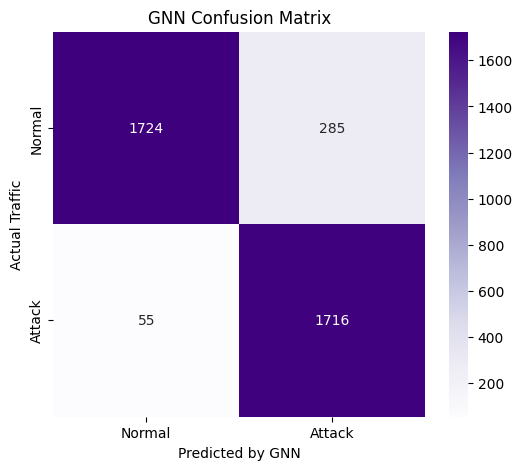

In [81]:
# %%
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    # Assuming your model outputs log_softmax, use torch.exp to get probabilities
    probs = torch.exp(model(data))[:, 1] # Get probabilities for class 1
    
    custom_threshold = 0.4
    pred_custom = (probs >= custom_threshold).int()

y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred_custom[data.test_mask].cpu().numpy()



print("\n--- GNN Classification Report ---")
print(classification_report(y_true, y_pred, target_names=["Normal", "Attack"]))

# Visualizing the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted by GNN')
plt.ylabel('Actual Traffic')
plt.title('GNN Confusion Matrix')
plt.savefig('5_Knn_GNN_paperInspired.png')
plt.show()